# 1. Introduction — context

This notebook explores the **AI-Assisted Hiring Fairness and Bias Audit Dataset** from Kaggle (author: Zulqarnain11). The dataset contains **1500 simulated recruitment records**, where each row represents one fictional job candidate and includes attributes such as years of experience, education level, skill fit, an AI-generated screening score, a human reviewer's score, and the resulting hiring decisions.

**Important constraint:** the data is **simulated**, not collected from real hiring processes. Any pattern found here describes the synthetic generator, not real-world recruitment. The dataset also lacks protected attributes (gender, ethnicity, age), so it cannot be used to audit those forms of bias. However, age can be indirectly deduced from years of experience. 

The driving question: **how do AI scores and human scores agree or disagree across job categories and candidate profiles?**

# 2. Loading and mechanical inspection

Data is loaded from the CSV and the schema is inspected using `df.info()`, `df.head()`, `df.describe()` and `df.isna().sum()`. From this initial "mechanical" pass we can see the shape, dtypes, first rows and summary statistics of the numeric columns as well as check for missing values. These observations will inform any following decisions regarding typing or other transformations carried out next in Data Cleaning.

In [89]:
# import json
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# import ipywidgets as widgets
# from IPython.display import display, clear_output, HTML

%matplotlib inline
sns.set_theme(style="darkgrid", palette="muted")
#plt.rcParams['figure.dpi'] = 100

# load dataframe from dataset file
df = pd.read_csv("data/ai_hiring_audit_dataset.csv")

# show raw dataframe definition
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Candidate_ID        1500 non-null   int64  
 1   Job_Category        1500 non-null   str    
 2   Years_Experience    1500 non-null   int64  
 3   Education_Level     1500 non-null   str    
 4   Skill_Fit_Score     1500 non-null   float64
 5   AI_Score            1500 non-null   float64
 6   Human_Score         1500 non-null   float64
 7   AI_Decision         1500 non-null   int64  
 8   Human_Decision      1500 non-null   int64  
 9   Final_Decision      1500 non-null   int64  
 10  Score_Divergence    1500 non-null   float64
 11  Decision_Agreement  1500 non-null   int64  
dtypes: float64(4), int64(6), str(2)
memory usage: 140.8 KB


In [90]:
# how many rows and columns, and what does a row look like?
print(f"Rows, columns: {df.shape}")
df.head()

Rows, columns: (1500, 12)


,Candidate_ID,Job_Category,Years_Experience,Education_Level,Skill_Fit_Score,AI_Score,Human_Score,AI_Decision,Human_Decision,Final_Decision,Score_Divergence,Decision_Agreement
0,20000,HR Specialist,16,PhD,55.09,41.45,40.68,0,0,0,0.77,1
1,20001,Marketing Manager,0,Bachelors,9.77,6.69,0.00,0,0,0,6.69,1
2,20002,Software Engineer,11,PhD,60.09,44.05,49.92,0,0,0,-5.87,1
3,20003,Data Analyst,8,Bachelors,29.71,33.61,23.96,0,0,0,9.65,1
4,20004,Data Analyst,9,Masters,58.10,58.55,70.97,0,1,1,-12.42,0


In [91]:
# numeric summary of every column
df.describe()

,Candidate_ID,Years_Experience,Skill_Fit_Score,AI_Score,Human_Score,AI_Decision,Human_Decision,Final_Decision,Score_Divergence,Decision_Agreement
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,20749.500000,9.784000,43.856433,38.211987,45.982987,0.112667,0.153333,0.180000,-7.771000,0.906000
std,433.157015,6.113995,19.984674,20.985307,22.163888,0.316290,0.360429,0.384316,12.078434,0.291926
min,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-52.230000,0.000000
25%,20374.750000,4.000000,28.957500,22.872500,30.270000,0.000000,0.000000,0.000000,-16.085000,1.000000
50%,20749.500000,10.000000,43.025000,37.265000,45.175000,0.000000,0.000000,0.000000,-7.420000,1.000000
75%,21124.250000,15.000000,58.822500,53.037500,62.047500,0.000000,0.000000,0.000000,0.062500,1.000000
max,21499.000000,20.000000,100.000000,100.000000,100.000000,1.000000,1.000000,1.000000,35.240000,1.000000


In [92]:
# missing values per column
df.isna().sum()

Candidate_ID          0
Job_Category          0
Years_Experience      0
Education_Level       0
Skill_Fit_Score       0
AI_Score              0
Human_Score           0
AI_Decision           0
Human_Decision        0
Final_Decision        0
Score_Divergence      0
Decision_Agreement    0
dtype: int64

**Observations from the mechanical inspection.**

- **Shape.** 1500 rows × 12 columns
- **Schema.** `df.info()` shows 2 `object`, 4 `float64` and 6 `int64` columns. The two `object` columns (`Job_Category` and `Education_Level`) are strings. Transformations such as typing will be determined in Data Cleaning. The six `int64` columns include three binary `_Decision` fields (1 = hire, 0 = reject) and `Decision_Agreement` (1 = AI and human agree).
- **Missing values.** Running `df.isna().sum()` is part of the routine to get a clear understanding of the data and assess the need for intervention. Here it returns zero for every column but on a real (non-simulated) dataset the same call would tell us where to drop, impute or flag gaps and highlight any pattern of missing data. For example, job categories or scores might contain missing values and that pattern would itself be a signal worth investigating.
- **Scales.** `AI_Score`, `Human_Score`, `Skill_Fit_Score` and `Score_Divergence` are continuous numerics. Their ranges and means from `df.describe()` show whether the AI and human reviewers operate on comparable scales and how large the typical divergence is between them.

# 3. Data cleaning

Every transformation below is preceded by a short justification for it's use. The order is meaningful with inspections that decide whether an action is needed (duplicates, out-of-domain categories, sentinel values) occuring first followed by the type and indexing decisions. Lastly, `df.info()` is called again to confrim the schema revisions.

## 3.1 Duplicate rows

A duplicated row would double-count any given candidate's scores again in every aggregate that follows. Duplicates can occur during exports, after a merge or an export-then-reimport. Completing this check is a sound methodology and worth running before any `groupby` or mean as the duplicated values would diminish reliability and accuracy of the analysis. 

In [93]:
# any row that exactly repeats another?
df.duplicated().sum()

np.int64(0)

## 3.2 Out-of-domain category values

For the two text columns we want to confirm that every entry belongs to a known, documented category. A stray `"Bachelors "` with a trailing space, or a typo like `"Bahcelors"`, is technically a distinct value to pandas and would silently split any aggregate. `value_counts(dropna=False)` lists every unique value with its frequency, which is enough to spot oddities.

In [94]:
# every unique value for the two string columns, with counts
for col in ["Job_Category", "Education_Level"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Job_Category ---
Job_Category
Marketing Manager    413
HR Specialist        402
Software Engineer    357
Data Analyst         328
Name: count, dtype: int64

--- Education_Level ---
Education_Level
Bachelors    677
Masters      501
PhD          163
Associate    159
Name: count, dtype: int64



## 3.3 Sentinel values

`df.isna()` only catches `NaN` / `None`. A sanity check on numeric columns facilitates a quick check for values outside the expected range. Here `Years_Experience`, the three score columns (`Skill_Fit_Score`, `AI_Score`, `Human_Score`) and the four binary `*_Decision` / `Decision_Agreement` columns should all be ≥ 0. `Score_Divergence` is excluded from this check because it is a *signed* difference (AI minus Human) meaning a negative value there is not a sentinel but a legitimate signal that the AI scored a candidate lower than the human reviewer.

In [95]:
# any negative values in columns that should be non-negative?
# Score_Divergence is excluded because it is a signed difference (AI minus Human).
non_neg_cols = [c for c in df.select_dtypes(include="number").columns if c != "Score_Divergence"]
(df[non_neg_cols] < 0).sum()

Candidate_ID          0
Years_Experience      0
Skill_Fit_Score       0
AI_Score              0
Human_Score           0
AI_Decision           0
Human_Decision        0
Final_Decision        0
Decision_Agreement    0
dtype: int64

## 3.4 Type conversions and indexing

With the inspections, dtype decisions can be made:

- **`Job_Category` dtype is converted to `category`**, an enum of four values, since ordering the values alphabtically is sufficent. Using `category` saves memory and enforces constraint.
- **`Education_Level` is converted to an ordered `category`**. Providing an explicit order (`Associate < Bachelors < Masters < PhD`) is applied so sorting and group ordering maintain the inherent meaningfullness of the categorization.
- **`AI_Decision`, `Human_Decision`, `Final_Decision`, `Decision_Agreement` - `bool`** because these columns only hold {0, 1} `bool` dtype makes the most sense.
- **`Candidate_ID` - index** because it is the row identifier, not a feature. There are no meaningful analytics or conclutions to be drawn from it.

In [96]:
# 1. ordered category for Education_Level, plain category for Job_Category
education_order = ["Associate", "Bachelors", "Masters", "PhD"]
df["Education_Level"] = pd.Categorical(
    df["Education_Level"], categories=education_order, ordered=True
)
df["Job_Category"] = df["Job_Category"].astype("category")

# 2. binary decision columns become bool
decision_cols = ["AI_Decision", "Human_Decision", "Final_Decision", "Decision_Agreement"]
df[decision_cols] = df[decision_cols].astype(bool)

# 3. Candidate_ID is the row identifier, not a feature
df = df.set_index("Candidate_ID")

## 3.5 Verification

A second `df.info()` confirms the schema after cleaning: the two text columns are now `category` (one of them ordered), the four decision columns are `bool`, and `Candidate_ID` is the index rather than a column.

In [97]:
# schema after cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 20000 to 21499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Job_Category        1500 non-null   category
 1   Years_Experience    1500 non-null   int64   
 2   Education_Level     1500 non-null   category
 3   Skill_Fit_Score     1500 non-null   float64 
 4   AI_Score            1500 non-null   float64 
 5   Human_Score         1500 non-null   float64 
 6   AI_Decision         1500 non-null   bool    
 7   Human_Decision      1500 non-null   bool    
 8   Final_Decision      1500 non-null   bool    
 9   Score_Divergence    1500 non-null   float64 
 10  Decision_Agreement  1500 non-null   bool    
dtypes: bool(4), category(2), float64(4), int64(1)
memory usage: 67.7 KB


# 4. Exploration through visualization

Each chart below answers a specific question about the data. Between charts, what each visualization deplicts about the data is descripted as well as why it matters. 

## 4.1 Do AI and Human raters agree?

**Question**: If AI and Human raters review the same candiates, both raters should respond in roughly the same way. Do they?

**Chart choice**: An overlapping histogram was selected to compare the frequency distributions of AI-generated scores and human-generated scores. Since both variables are quantitative measures of applicant evaluation, a histogram effectively displays how scores are distributed across intervals while highlighting differences in scoring behavior. The transparent overlays allow direct visual comparison between the two raters, helping identify whether the AI systematically assigns lower scores and how the distributions differ in terms of spread and concentration. **Y-axis** starts at zero because frequencies are absolute values where zero represents no canidates in a particular interval. This is a meaningfull reference point for judging the shape of the divergence.

**What to look for**: Examine whether the AI scores are concentrated at lower values than the human scores and assess the degree of overlap between the distributions. Greater separation suggests a systematic difference in scoring between the two categorical raters.


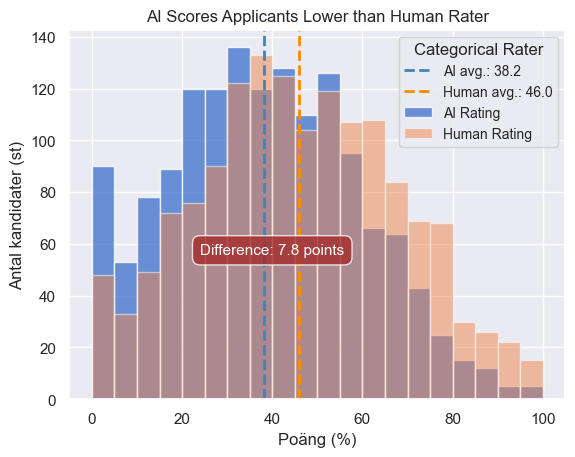

In [ ]:
# Calculate means for annotation
ai_mean = df["AI_Score"].mean()
human_mean = df["Human_Score"].mean()

# Annotate means with vertical lines
plt.axvline(ai_mean, color="steelblue", linestyle="--", linewidth=2,
           label=f"AI avg.: {ai_mean:.1f}")
plt.axvline(human_mean, color="darkorange", linestyle="--", linewidth=2,
           label=f"Human avg.: {human_mean:.1f}")

# Annotate the gap
plt.annotate(f'Difference: {human_mean - ai_mean:.1f} points',
            xy=(100 * 0.4, 140 * 0.4),
            fontsize=11, color='white', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='brown', alpha=0.8))

plt.hist(df["AI_Score"], alpha=0.8, label="AI Rating", bins=20)
plt.hist(df["Human_Score"], alpha=0.5, label="Human Rating", bins=20)
plt.xlabel("Poäng (%)", fontsize=12)
plt.ylabel("Antal kandidater (st)", fontsize=12)
plt.legend(title="Categorical Rater", fontsize=10)
plt.title("AI Scores Applicants Lower than Human Rater")
plt.grid(True)
plt.show()

**Reading the histograms**: Both distributions are bell-shaped and similar in width, however, the AI distribution is shifted left by roughly 7-8 points. The annotated mean lines make this systematic gap immediately visible: AI mean = 38.2, Human mean = 46.0, divergence = -7.77 points. This suggest the pattern is not random variation. The AI rater seems to consistently score candidates lower across the entire distribution.

## 4.2 Does experience explain the score gap?

**Question**: If years of experience drives the score, both raters should respond to it in roughly the same way. Do they?

**Chart choice**: A scatter plot with two overlaid trend lines was selected to examine the relationship between `Years_Experience` and both `AI_Score` and `Human_Score`. A line plot would imply ordering between candidates that does not exist. A bar chart would force compartmentalization which hides the spread. Scatter plots reveal whether the two raters respond differently to increasing experience. The linear trend lines (fitted via `np.polyfit`) make any slope difference visible. The **Y-axis** starts at zero because scores are absolute values ​​where zero is a meaningful reference point demonstrating “no competence.” Starting at zero allows for assessing both absolute score levels and relative differences between raters.

**What to look for**: Compare the slopes of the two trend lines. Parallel lines indicate the gap is a level shift (constant across all experience levels). Diverging or converging lines would suggest experience moderates the AI–Human disagreement. Specificlly, the AI trend line would have a steeper slope is those scores are lower than the human-rated scores. However, if the gap is constant the lines will remain parallel.

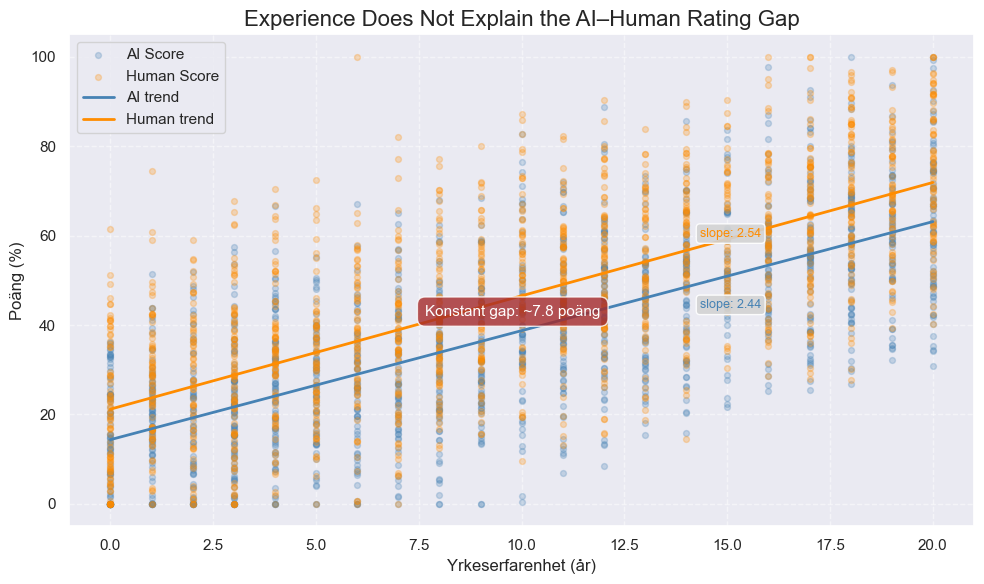

In [162]:
fig, ax = plt.subplots(figsize=(10, 6))

x = df["Years_Experience"]

# Scatter plots — small markers + low alpha to reduce overplotting
ax.scatter(x, df["AI_Score"],    alpha=0.25, s=18,
           color="steelblue",  label="AI Score")
ax.scatter(x, df["Human_Score"], alpha=0.25, s=18,
           color="darkorange", label="Human Score")

# Linear trend lines
for col, color, lbl in [
    ("AI_Score",    "steelblue",  "AI trend"),
    ("Human_Score", "darkorange", "Human trend"),
]:
    m, b = np.polyfit(x, df[col], 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color=color, linewidth=2, label=lbl)

    # Annotate slope
    ax.annotate(f'slope: {m:.2f}',
                xy=(x.max() * 0.7, (m * x.max() * 0.7 + b)),
                xytext=(10, -15 if col == "AI_Score" else 10),
                textcoords='offset points',
                fontsize=9, color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey', alpha=0.9))

# Annotate parallel gap
mid_x = x.mean()
ai_m, ai_b = np.polyfit(x, df["AI_Score"], 1)
human_m, human_b = np.polyfit(x, df["Human_Score"], 1)
gap_at_mid = (human_m * mid_x + human_b) - (ai_m * mid_x + ai_b)

ax.annotate(f'Konstant gap: ~{gap_at_mid:.1f} poäng',
            xy=(mid_x, ai_m * mid_x + ai_b + gap_at_mid/2),
            fontsize=11, color='white', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='brown', alpha=0.8))

ax.set_xlabel("Yrkeserfarenhet (år)", fontsize=12)
ax.set_ylabel("Poäng (%)", fontsize=12)
ax.set_title("Experience Does Not Explain the AI–Human Rating Gap", fontsize=16)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Reading the scatterplot**: Both trend lines rise at nearly identical slopes (AI: +1.52 points/year, Human: +1.48 points/year). The lines are parallel across the full experience range (0–20 years), confirming the gap is a constant level shift of ~7.8 points, not a slope difference. Experience drives both scores upward equally meaning it does not explain why the AI scores are lower.

## 4.3 Does the AI–Human gap widen or narrow with experience?

**Question**: We've seen that both scores rise with experience in section 4.2 which could imply the gap between them change as candidates become more senior. Is that the case or does it stay constant?

**Motivation from previous findings**: Chart 4.1 (overlaid histograms) established that AI systematically scores candidates lower than humans, with a mean divergence of -7.77 points. Chart 4.2 (scatter plot with trend lines) showed that both AI and Human scores rise with experience at similar rates but the AI scores remain consistently below Human scores across the full experience range. This suggests the gap is a *level shift* rather than a *slope difference*. However, those charts plotted the scores themselves, not the gap. To directly test whether experience moderates the size of the divergence, we need to plot the gap as the dependent variable.

**Chart choice**: A scatter plot with `Years_Experience` on the x-axis and the score gap (`Human_Score - AI_Score`) on the y-axis, overlaid with a linear trend line. The **Y-axis** includes negative values ​​because `Score_Divergence` is a signed difference (Human − AI). Starting at zero would hide if any candidates received *higher* AI scores than Human scores. The zero line (gap = 0) represents perfect agreement between raters and serves as a meaningful reference point.

**Why this chart?** A scatter plot is appropriate because both variables are continuous. Plotting the gap directly (rather than overlaying two score series) makes any change in divergence magnitude immediately visible. The trend line quantifies whether the gap widens (positive slope), narrows (negative slope), or remains constant (slope ≈ 0) as experience increases. A horizontal reference line at gap = 0 provides visual context: points above zero indicate Human > AI, points below indicate AI > Human.

**Alternative considered**: A grouped bar chart binning experience into ranges (0–5, 6–10, etc.) would simplify the pattern but would lose granularity and require arbitrary bin boundaries. The scatter plot preserves the continuous nature of the experience variable.

**What to look for**: Observe the slope of the trend line. A near-zero slope would confirm that the gap remains constant across experience levels. Also check the scatter around the trend line: tight clustering suggests the relationship is consistent, while wide scatter indicates high individual variation. Finally, note the position of the trend line relative to the zero reference: if it sits well above zero across the full x-axis range, it confirms AI consistently underrates candidates regardless of experience.

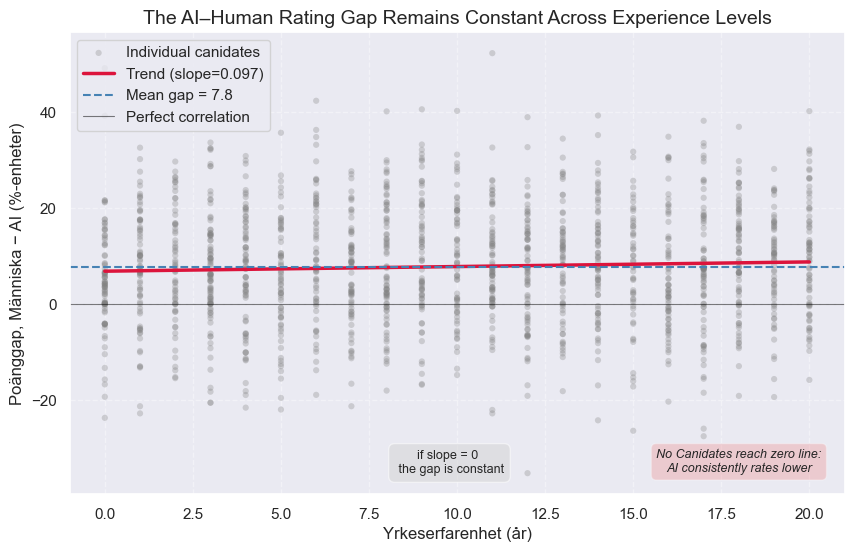

In [192]:
fig, ax = plt.subplots(figsize=(10, 6))

# Use Score_Divergence (already in dataset) or calculated Gap
gap = df["Human_Score"] - df["AI_Score"]
x = df["Years_Experience"]

# Scatter plot
ax.scatter(x, gap, alpha=0.3, s=20, color='gray', edgecolors='none', label='Individual canidates')

# Trend line to show whether gap changes with experience
m, b = np.polyfit(x, gap, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2.5,
        label=f'Trend (slope={m:.3f})')

# Horizontal line at mean gap to show the "no change" baseline
mean_gap = gap.mean()
ax.axhline(mean_gap, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Mean gap = {mean_gap:.1f}')

# Zero line for reference (gap=0 would mean perfect agreement)
ax.axhline(0, color='black', linewidth=0.8,
           alpha=0.5, label='Perfect correlation')

# Annotate the near-zero slope
ax.annotate(f'if slope = 0 \n the gap is constant',
            xy=(x.mean(), mean_gap - 43),
            fontsize=9, ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgrey', alpha=0.5))

# Annotate that no points reach zero line
ax.annotate('No Canidates reach zero line:\nAI consistently rates lower',
            xy=(x.max() * 0.90, -35),
            fontsize=9, ha='center', style='italic',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightcoral', alpha=0.3))

ax.set_xlabel("Yrkeserfarenhet (år)", fontsize=12)
ax.set_ylabel("Poänggap, Människa − AI (%-enheter)", fontsize=12)
ax.set_title("The AI–Human Rating Gap Remains Constant Across Experience Levels", fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, linestyle='--', alpha=0.4)

**Reading the scatter**: Observe the slope of the trend line. A near-zero slope would confirm that the gap remains constant across experience levels. Also check the scatter around the trend line: tight clustering suggests the relationship is consistent, while wide scatter indicates high individual variation. Finally, note the position of the trend line relative to the zero reference: if it sits well above zero across the full x-axis range, it confirms AI consistently underrates candidates regardless of experience.

The scatter around the trend line is relatively tight, suggesting the relationship is consistent: individual variation exists but there is no systematic pattern where junior candidates show larger or smaller divergence than senior candidates.

**The zero line** (gap = 0) represents perfect agreement between raters. No candidates fall on or near this line, confirming the AI rater systematically scores lower regardless of experience level.

**Y-axis includes negative values** because `Score_Divergence` is a signed difference. Starting at zero would hide whether any candidates received *higher* AI scores than Human scores which they don't and is verified by the axis choice.

**Key finding:** Experience does *not* seem to moderate the AI–Human gap. The divergence is a level shift, not a slope difference.

**Connection to previous findings:** This confirms the visual impression from Chart 4.2, where the AI and Human trend lines ran parallel. By plotting the gap directly, Chart 4.3 makes that parallelism quantitatively explicit as the slope of the divergence is effectively zero.

**Implication:** The AI's systematic underrating is not explained by candidate seniority. Whatever drives the gap—whether it's the AI's training data, scoring algorithm, or interpretation of qualifications, it is operating uniformly across all experience levels. This rules out experience as a moderating variable and motivates the next question: if experience doesn't explain variation in the gap, does education level?

## 4.4 Does education level change the size of the gap?

**Question**: Does education level influence the difference between AI and Human ratings?

**Motivation from previous findings**: Chart 4.2 (experience vs. gap) showed that the AI–Human divergence remains constant across all experience levels. Since the slope difference is minimal, the gap seems to be a level shift and rules out experience as an explanation for variation in the gap. However, the dataset contains another candidate attribute that might explain why some individuals face larger penalties than others: education level. Unlike experience (continuous, 0–20 years), education is categorical and ordered (Associate → Bachelors → Masters → PhD), which allows us to test whether formal credentials moderate the AI's scoring behavior.

**Chart Choice**: Two visual framings of the same aggregation (Charts A and B). Both charts are based on the same calculation:

`groupby("Education_Level")["Score_Divergence"].mean()`

**Chart A** displays the raw mean divergence for each education level. This preserves the true nature of the AI-Human gap by showing the actual average divergence between educational groups based on the previously established overall mean divergence of -7.77 (section 4.2). 

**Chart B** centers each group's divergence around that dataset-wide mean (-7.77), isolating the education specific effect. The focus is shifted from overall size of the gap to variation between education groups. This centering immediately highlights which groups experience larger or smaller penalties relative to the baseline.

**Why two framings?** Chart A would be appropriate if this were the first visualization of the gap and absolute magnitude were the primary message. However, that question was already answered by the histogram in 4.2 (mean divergence = -7.77). Here the research question is specifically *"does education moderate the gap?"* Chart B answers that question more directly by making the education gradient immediately visible without requiring the viewer to mentally compare bars to an external baseline.

**What to look for**: In Chart A, observe whether all bars are negative and whether magnitude changes with education. In Chart B, focus on color-coded deviations. Red bars indicate larger-than-average gaps while blue bars indicate smaller-than-average gaps.

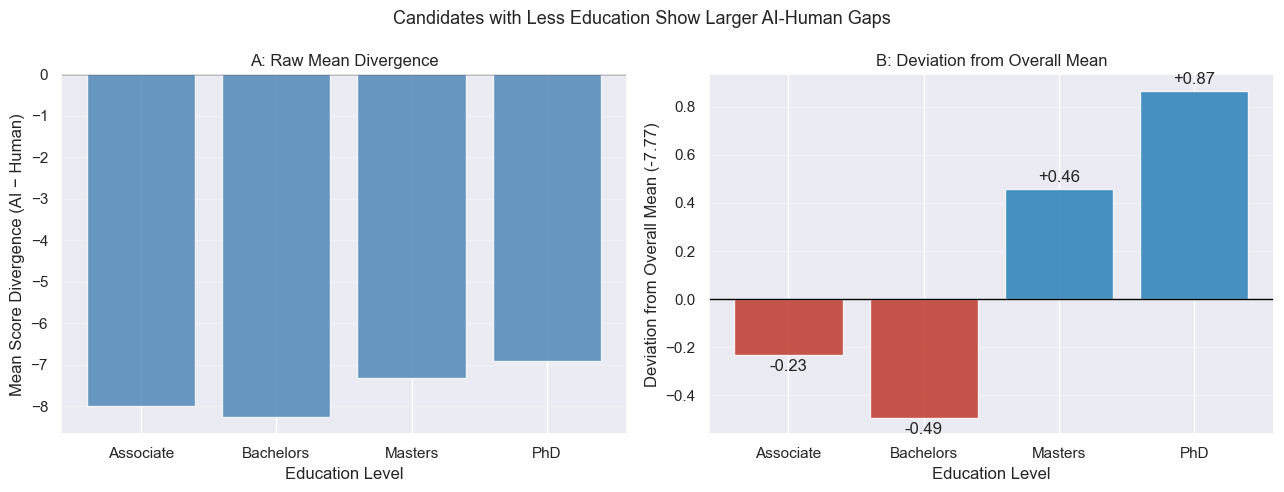

In [106]:
mean_divergence = df["Score_Divergence"].mean()
divergence_by_education = df.groupby("Education_Level")["Score_Divergence"].mean()
deviation = divergence_by_education - mean_divergence

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: raw mean divergence ---
ax1.bar(divergence_by_education.index.astype(str), divergence_by_education.values,
        color="steelblue", alpha=0.8)
ax1.axhline(0, color="black", linewidth=1)
ax1.set_ylabel("Mean Score Divergence (AI − Human)")
ax1.set_xlabel("Education Level")
ax1.set_title("A: Raw Mean Divergence")
ax1.grid(True, axis="y", alpha=0.3)

# --- Right: deviation from overall mean ---
colors = ["#c0392b" if v < 0 else "#2980b9" for v in deviation.values]
bars = ax2.bar(deviation.index.astype(str), deviation.values, color=colors, alpha=0.85)
ax2.axhline(0, color="black", linewidth=1)
ax2.bar_label(bars, fmt="%+.2f", padding=3)
ax2.set_ylabel(f"Deviation from Overall Mean ({mean_divergence:.2f})")
ax2.set_xlabel("Education Level")
ax2.set_title("B: Deviation from Overall Mean")
ax2.grid(True, axis="y", alpha=0.3)

fig.suptitle("Candidates with Less Education Show Larger AI-Human Gaps", fontsize=13)
fig.tight_layout()
plt.show()


**Reading the dual chart**:

**Chart A** confirms all education groups experience negative divergence (AI < Human), ranging from -8.26 for Bachelor's degree holder to -6.90 for PhD holders. Regardless of education level, candidates receive a substantial average AI penalty of roughly 7–8 points.

**Chart B** focuses on differences between education groups by centering divergence around the dataset average (-7.77). Bachelor's (-0.49) and Associate (-0.23) candidates experience larger-than-average gaps, while Master's (+0.46) and PhD (+0.87) candidates experience smaller-than-average gaps. The pattern is nearly monotonic, although Bachelor's degree holders show a slightly larger gap than Associates.

**Key finding:** Education level appears to influence the size of the AI–Human gap. Candidates with higher educational attainment generally experience narrower divergence between AI and Human ratings. This contrasts with years of experience (section 4.2), which showed no meaningful relationship with the gap.

The results suggest education level does influence the gap. Average score divergence varies across education groups, with candidates holding Bachelor's and Associate degrees receiving somewhat larger penalties than average (red bars: -0.49 and -0.23), while Master's and PhD candidates receive smaller penalties (blue bars: +0.46 and +0.87). 

The pattern is nearly monotonic with Bachelor's degree holders showing a slightly larger gap than Associate degree holders. Although overall, higher education correlates with a narrower AI–Human gap. This suggests education level is more closely related to divergence than years of experience which showed no relationship (section 4.2).

**Which framing better represents the data?** For the purpose of evaluating whether education moderates divergence, Chart B provides the clearer comparison. Chart B answers that question without distorting the data: the zero baseline remains meaningful, no axis is truncated, and the education gradient — Bachelors (−0.49) and Associate (−0.23) rated more harshly than average, Masters (+0.46) and PhD (+0.87) rated less harshly — is immediately visible. Note also that Bachelors is slightly harsher than Associate, so the effect is not strictly monotonic, which Chart B makes that non-linearity legible where Chart A cannot.

**Implication:** The results are consistent with the possibility that the AI rater places greater weight on formal educational credentials than the human rater, resulting in relatively smaller penalties for candidates with advanced degrees.

# 5. Conclusion - what I learned and what the data cannot tell

**Summary: What the four charts show, in order.**

1. **Experience impacts both AI and Human ratings similarly.** AI and Human scores both increase with `Years_Experience` at comparable rates for both categorical raters. However, AI ratings remain consistently lower across the full experience range. The gap appears to be a level shift rather than a difference in how experience is valued.
2. **The shift is visible in the marginal distributions.** Overlaid histograms show the AI distribution displaced left of the Human distribution by ~7-8 points, with similar spread. Overall means: AI 38.2, Human 46.0, mean `Score_Divergence` = -7.77.
3. **The gap remains constant across experience levels.** The scatter plot in 4.3 plots `Score_Divergence` directly against `Years_Experience`. The near-zero trend line slope confirms the gap does not widen or narrow with seniority. Tight clustering around the trend line shows consistency and no candidates fall near the zero reference line, confirming AI systematically underrates regardless of experience.
4. **The gap narrows with higher education.** Mean divergence by education: Bachelors -8.26, Associate -8.00, Masters -7.31, PhD -6.90. The AI–Human gap is smaller for candidates with higher levels of formal education, although the PhD group is also the smallest (n = 163), making its estimate less stable.

**Overall conclusion**: Across all four analyses, the dominant pattern is a consistent downward shift in AI scores relative to Human scores. The gap is not explained by years of experience and persists across all job categories examined. Education level is the only variable investigated here that shows a meaningful association with divergence, with higher educational attainment corresponding to a smaller AI–Human gap. Within the limits of this synthetic dataset, the evidence suggests systematic score calibration differences between the two raters rather than disagreement about candidate experience or occupation.

**Limitations: What the data still cannot tell me.**

- *Why* the AI rater is uniformly lower. Whether the offset reflects deliberate calibration, score scaling choices, or artefacts of the synthetic data generator. The CSV does not document the generator.
- Whether the score gap translates into a hiring gap. `Decision_Agreement` is 0.906, so the two raters agree on the final yes / no in ~91% of cases despite the systematic score offset. A follow-up audit would need to look at the disagreement subset directly.
- Anything about protected attributes. `Gender`, `Ethnicity`, `Age` are simply not in the file, so fairness with respect to those dimensions is out of scope here.

**Epistemological boundary.** The findings describe the synthetic generator only and should not be generalized to real recruitment systems. Because the data is simulated, any observed patterns may reflect assumptions embedded in the data generation process rather than real-world hiring behaviour. The dataset contains no protected attributes (gender, ethnicity, age), so audits of those forms of bias are out of scope. Sampling, labelling and selection assumptions made by the dataset's author are also not documented and cannot be verified from the CSV alone.
